# PU experiments

In [1]:
import os
import pandas as pd
import numpy as np
from data.datasets import get_pd_dataset,prepare_and_split_data
from data.dataset_helpers import SAR
from config import CONFIG
import matplotlib.pyplot as plt
from classifiers.TM_log_reg import TwoModelLogReg
from classifiers.classic_log_reg import ClassicLogReg
from classifiers.naive_log_reg import NaiveLogReg
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,classification_report
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import seaborn as sns
import numpy.random as rng
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import warnings
from sklearn.exceptions import ConvergenceWarning
import json

import warnings
warnings.filterwarnings("ignore")

In [2]:
datasets = ["mock","diabetes","breastcancer","mnist"]

In [3]:
models = {
    "classic": ClassicLogReg(),
    "naive": NaiveLogReg(),
    "two_model": TwoModelLogReg()
}

In [4]:
def describe_dataset(data,name):
    print(f"\n \nDataset: {name} \n")
    n_sampels = data.shape[0]
    n_features = data.shape[1]-1    
    class_balance = data["target"].sum()/n_sampels
    print(f"Number of samples: {n_sampels}")
    print(f"Number of features: {n_features}")
    print(f"Class balance (positive class): {class_balance:.2f} \n")
    X_train,X_test,y_train,y_test = train_test_split(data.drop(columns=["target"]), data["target"], test_size=0.2, random_state=42)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    clf = LogisticRegression(verbose=0)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).T)


for dataset in datasets:
    data = get_pd_dataset(name=dataset)
    describe_dataset(data,name=dataset)



 
Dataset: mock 

Number of samples: 3315
Number of features: 4
Class balance (positive class): 0.02 

              precision    recall  f1-score     support
0              0.978852  0.998459  0.988558  649.000000
1              0.000000  0.000000  0.000000   14.000000
accuracy       0.977376  0.977376  0.977376    0.977376
macro avg      0.489426  0.499230  0.494279  663.000000
weighted avg   0.958182  0.977376  0.967684  663.000000

 
Dataset: diabetes 

Number of samples: 768
Number of features: 8
Class balance (positive class): 0.35 

              precision    recall  f1-score     support
0              0.812500  0.787879  0.800000   99.000000
1              0.637931  0.672727  0.654867   55.000000
accuracy       0.746753  0.746753  0.746753    0.746753
macro avg      0.725216  0.730303  0.727434  154.000000
weighted avg   0.750154  0.746753  0.748167  154.000000

 
Dataset: breastcancer 

Number of samples: 569
Number of features: 30
Class balance (positive class): 0.63 

     

# label frequency

In [23]:
path = "/Users/cas/Documents/naive_pu/EXPERIMENTS/LABELING_MECHANISM/final_869.pkl"
df = pd.read_pickle(path)
df["accuracy"].unique()
# df = df[df["c"]<=1]
# df = df[df["c"]>0.8]
# df = df[df["model"]!="oracle"].copy()

# path = "/Users/cas/Documents/naive_pu/EXPERIMENTS/c/0.8_mnist_oracle_9.pkl"
# df = pd.read_pickle(path)
# df["accuracy"].unique()
# df = df[df["c"]<=0.8]
# df_8 = df[df["model"]!="oracle"].copy()
# df = pd.concat([df_8,df_9])

array([0.98039216, 0.01960784, 0.760181  , 0.73453997, 0.71644042,
       0.75263952, 0.73001508, 0.75414781, 0.64856712, 0.60935143,
       0.72699849, 0.70889894, 0.65584416, 0.35064935, 0.71428571,
       0.74025974, 0.64935065, 0.72077922, 0.74675325, 0.67532468,
       0.69480519, 0.66883117, 0.75324675, 0.68181818, 0.7012987 ,
       0.66233766, 0.68831169, 0.52212389, 0.87610619, 0.91150442,
       0.97345133, 0.61946903, 0.84955752, 0.96460177, 0.60176991,
       0.88495575, 0.61061947, 0.92035398, 0.99115044, 0.86725664,
       0.92920354, 0.50442478, 0.81415929, 0.94690265, 0.85840708,
       0.90265487, 0.98230088, 0.84070796, 0.53097345, 0.89380531,
       0.51911668, 0.9845089 , 0.        , 0.53065775, 0.93273876,
       0.98945287, 0.93125232, 0.98648649, 0.49692808, 0.99530177,
       0.79227053, 0.93719807, 0.5112782 , 0.93913355, 0.9509488 ,
       0.71945701, 0.6546003 , 0.64253394, 0.74811463, 0.86877828,
       0.65007541, 0.67873303, 0.62594268, 0.61689291, 0.64285

In [24]:
df

,LABELING_MECHANISM,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support
0,SCAR_1_1,mock,0,classic,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
1,SCAR_1_1,mock,0,naive,0.019608,0.000000,0.019608,0.000000,1.000000,0.000000,0.038462,650,13
2,SCAR_1_1,mock,0,two_model,0.760181,0.988072,0.043750,0.764615,0.538462,0.862099,0.080925,650,13
3,SCAR_1_1,mock,0,oracle,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
4,SCAR_1_1,mock,1,classic,0.980392,0.980392,0.000000,1.000000,0.000000,0.990099,0.000000,650,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,casecontrol_100,mnist,8,oracle,0.511278,0.511278,0.000000,1.000000,0.000000,0.676617,0.000000,1428,1365
1916,casecontrol_100,mnist,9,classic,0.511278,0.511278,0.000000,1.000000,0.000000,0.676617,0.000000,1428,1365
1917,casecontrol_100,mnist,9,naive,0.942356,0.970304,0.916321,0.915266,0.970696,0.941982,0.942725,1428,1365
1918,casecontrol_100,mnist,9,two_model,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0


In [25]:
mock = df[df["dataset"]=="mock"].copy()
diabetes = df[df["dataset"]=="diabetes"].copy()
breastcancer = df[df["dataset"]=="breastcancer"].copy()
mnist = df[df["dataset"]=="mnist"].copy() 
print(f"Shapes {mock.shape}, {diabetes.shape}, {breastcancer.shape}, {mnist.shape}")  

Shapes (480, 13), (480, 13), (480, 13), (480, 13)


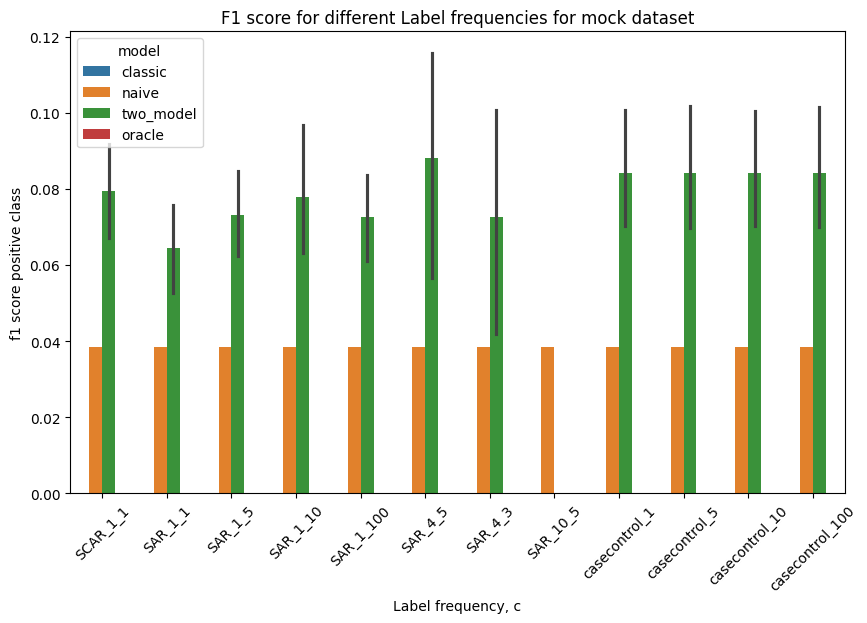

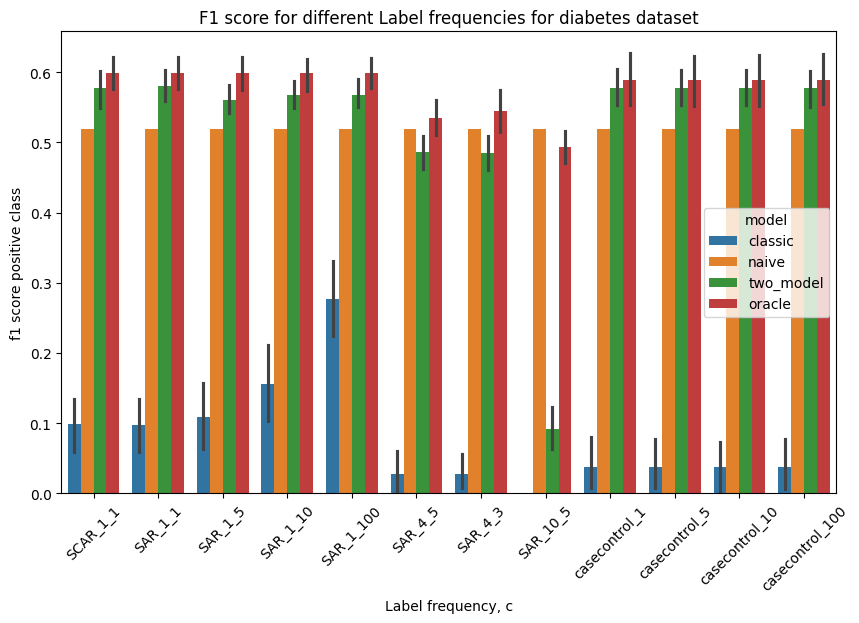

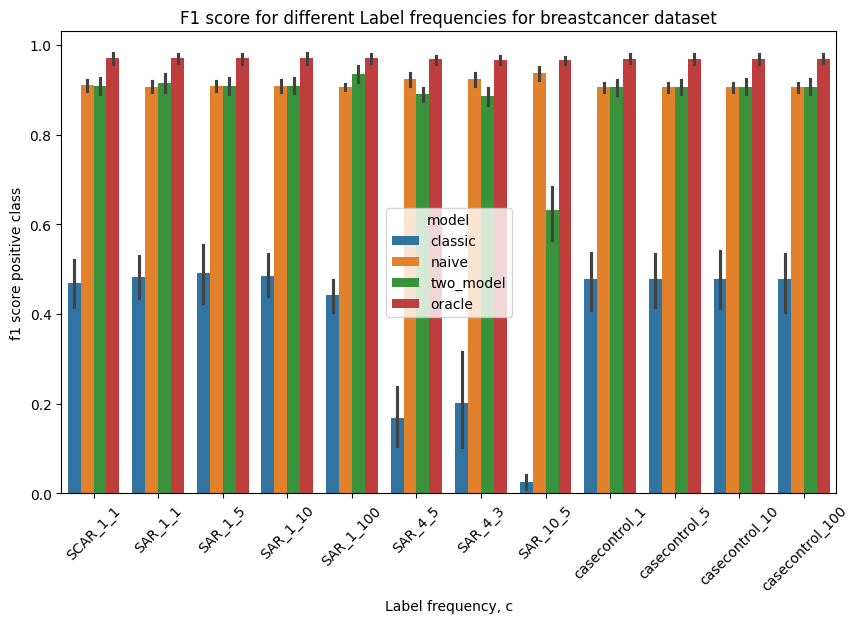

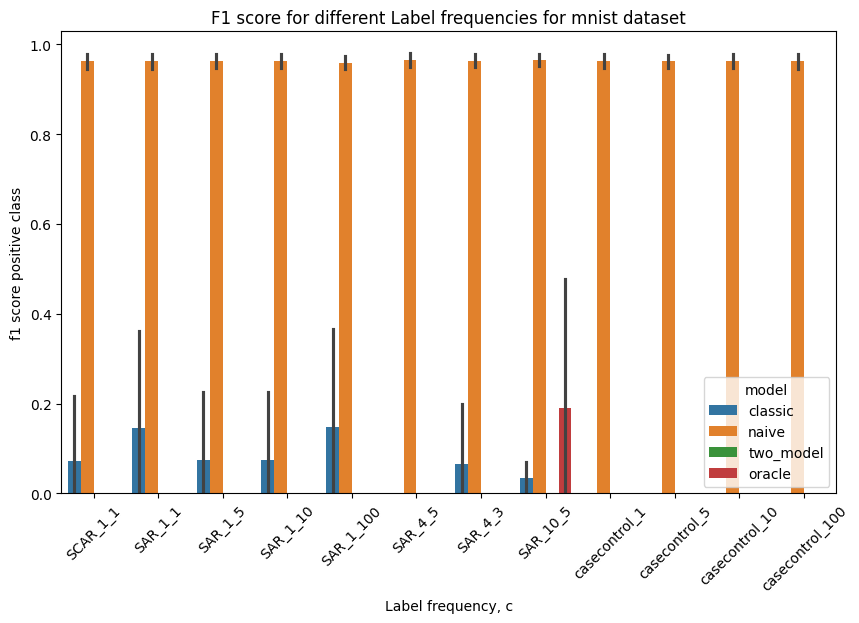

In [33]:


for name,data in zip(datasets,[mock,diabetes,breastcancer,mnist]):
    plt.figure(figsize=(10,6))
    sns.barplot(data=data, x="LABELING_MECHANISM", y="1 f1", hue="model")
    plt.title(f"F1 score for different Label frequencies for {name} dataset")
    plt.ylabel(r"f1 score positive class")
    plt.xlabel("Label frequency, c")
    plt.xticks(rotation=45)
    # plt.savefig(f"graphs/c_{name}_f1.png")
    # sns.lineplot(data=data, x="c", y=1 precision", hue="model", marker="o", linestyle="--")
    # sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o", linestyle=":")



In [9]:
mock

,c,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support
0,0.005,mock,0,classic,0.980392,0.980392,0.000000,1.00,0.000000,0.990099,0.000000,650,13
1,0.005,mock,0,naive,0.019608,0.000000,0.019608,0.00,1.000000,0.000000,0.038462,650,13
2,0.005,mock,0,two_model,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0,0
3,0.005,mock,0,oracle,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0,0
4,0.005,mock,1,classic,0.980392,0.980392,0.000000,1.00,0.000000,0.990099,0.000000,650,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1155,1.000,mock,8,oracle,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0,0
1156,1.000,mock,9,classic,0.980392,0.980392,0.000000,1.00,0.000000,0.990099,0.000000,650,13
1157,1.000,mock,9,naive,0.019608,0.000000,0.019608,0.00,1.000000,0.000000,0.038462,650,13
1158,1.000,mock,9,two_model,0.680241,0.991031,0.041475,0.68,0.692308,0.806569,0.078261,650,13


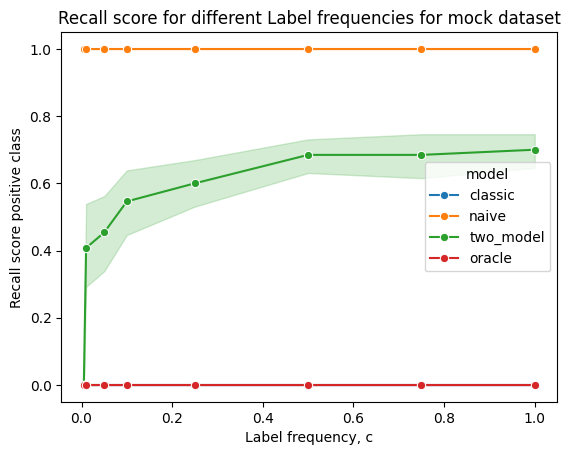

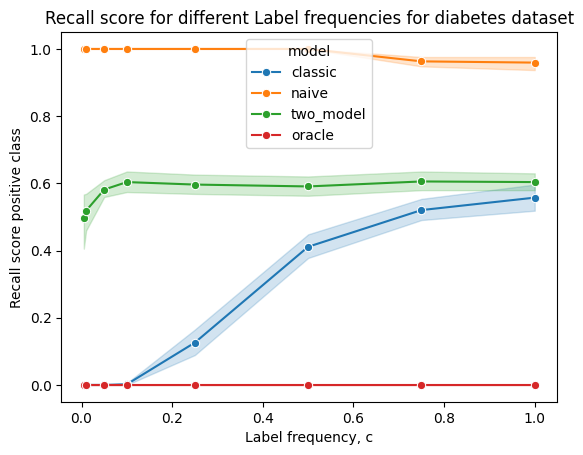

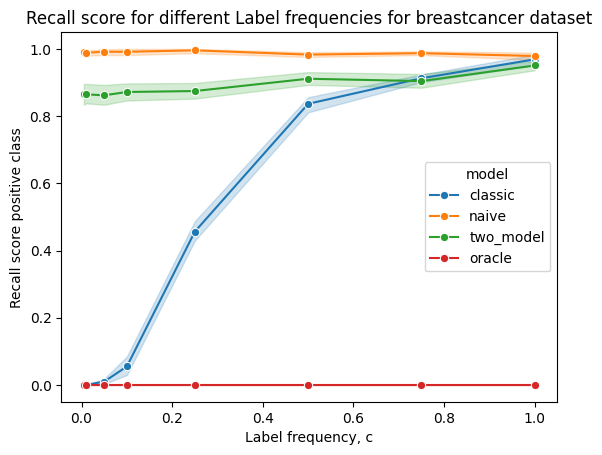

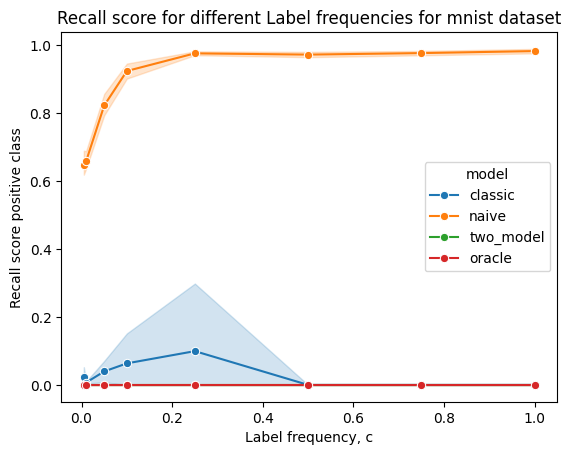

In [10]:
for name,data in zip(datasets,[mock,diabetes,breastcancer,mnist]):
    plt.figure()
    sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o")
    plt.title(f"Recall score for different Label frequencies for {name} dataset")
    plt.ylabel(r"Recall score positive class")
    plt.xlabel("Label frequency, c")
    #plt.savefig(f"graphs/c_{name}_recall.png")

    # sns.lineplot(data=data, x="c", y="1 precision", hue="model", marker="o", linestyle="--")
    # sns.lineplot(data=data, x="c", y="1 recall", hue="model", marker="o", linestyle=":")


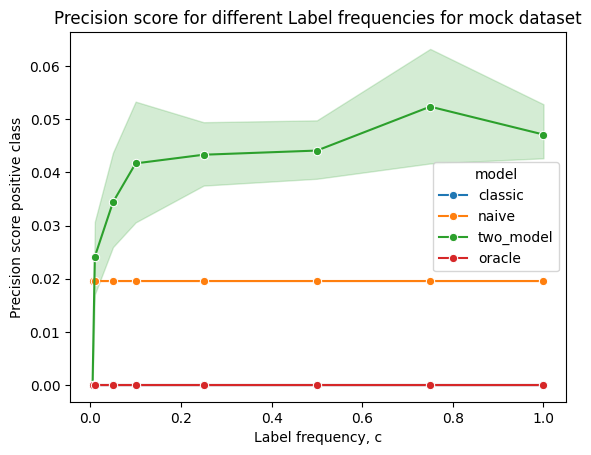

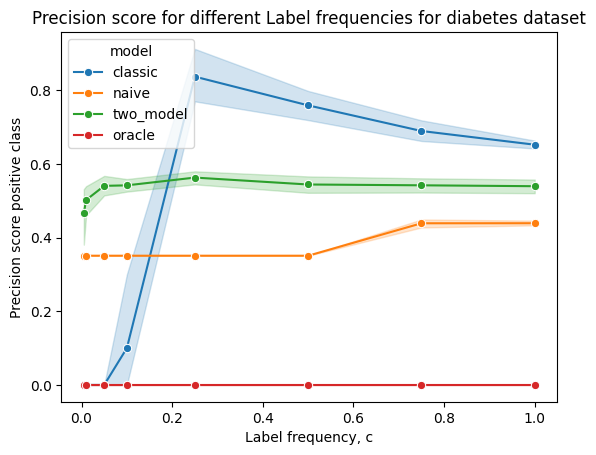

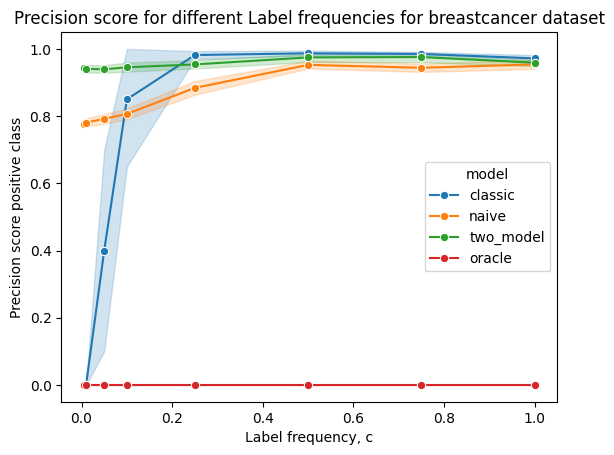

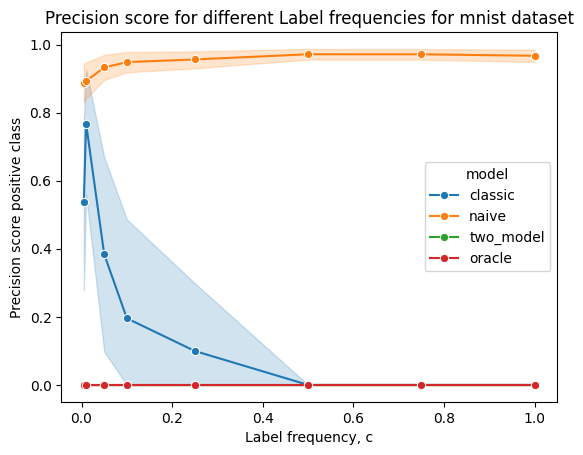

In [11]:
for name,data in zip(datasets,[mock,diabetes,breastcancer,mnist]):
    plt.figure()
    sns.lineplot(data=data, x="c", y="1 precision", hue="model", marker="o")
    plt.title(f"Precision score for different Label frequencies for {name} dataset")
    plt.ylabel(r"Precision score positive class")
    plt.xlabel("Label frequency, c")
    #plt.savefig(f"graphs/c_{name}_recall.png")

In [12]:
global DATASETS #Datasets to use for experiments
global MODELS #Classifiers to use for experiments
global ITERS #Amount of iterations per experiment
global STEP_RESULT #Template for each iteration result
global RESULT_COLS #Columns for the result dataframe

global EXPERIMENT_VALUES #Values to use for the current experiment
global EXPERIMENT_ATTR  #Attribute to vary for the current experiment, must equal one of the CONFIG attributes

#2 var experiment_attr_2
global EXPERIMENT_ATTR_2
global EXPERIMENT_VALUES_2

def set_global_vars():
    global DATASETS
    DATASETS = {"mock":get_pd_dataset(name="mock"),"diabetes":get_pd_dataset(name="diabetes"),"breastcancer":get_pd_dataset(name="breastcancer"),"mnist":None}

    global MODELS
    MODELS = {
    "classic": ClassicLogReg(),
    "naive": NaiveLogReg(),
    "two_model": TwoModelLogReg(),
    "oracle": ClassicLogReg()
    }

    global ITERS
    ITERS = np.arange(0,10,1)

    global STEP_RESULT
    STEP_RESULT = set_step_result()
    global RESULT_COLS
    RESULT_COLS = STEP_RESULT.index.tolist()

#Each iteration result template
def set_step_result():
    return pd.Series({
    "accuracy":0.0,
    "0 precision":0.0,
    "1 precision":0.0,
    "0 recall":0.0,
    "1 recall":0.0,
    "0 f1":0.0,
    "1 f1":0.0,
    "0 support":0,
    "1 support":0
}, name="results")

#Evaluate one iteration
def evaluate_step(y_test,y_pred):
    result_series = STEP_RESULT
    result_series["accuracy"] = accuracy_score(y_test, y_pred)
    result_series["0 precision"] = precision_score(y_test, y_pred, pos_label=0)
    result_series["1 precision"] = precision_score(y_test, y_pred, pos_label=1)
    result_series["0 recall"] = recall_score(y_test, y_pred, pos_label=0)
    result_series["1 recall"] = recall_score(y_test, y_pred, pos_label=1)
    result_series["0 f1"] = f1_score(y_test, y_pred, pos_label=0)
    result_series["1 f1"] = f1_score(y_test, y_pred, pos_label=1)
    result_series["0 support"] = sum(y_test == 0)
    result_series["1 support"] = sum(y_test == 1)
    return result_series

#Create the dataframe to store all experiment results, multiindex from all experiment parameters 
def make_test_result_df(sets,columns):    
    X = pd.MultiIndex.from_product(sets,names=columns).to_frame(index=False)
    X["accuracy"] = 0.0
    X["0 precision"] = 0.0
    X["1 precision"] = 0.0
    X["0 recall"] = 0.0
    X["1 recall"] = 0.0
    X["0 f1"] = 0.0
    X["1 f1"] = 0.0
    X["0 support"] = 0
    X["1 support"] = 0

    return X


set_global_vars()

In [13]:
naief = []
klassiek=[]
twee = []
mnist = "mnist"
for label_freq in [0.01,0.1,0.4,0.8,1]:
    print(f"\n Label frequency: {label_freq} \n")
    digits = str(np.random.choice(["1_7", "3_5", "3_8", "5_8", "6_9"], replace=False))
    name = f"mnist_{digits}"
    data = get_pd_dataset(name=name)
    X_train,s_train,X_test,y_test = prepare_and_split_data(data,c=label_freq)
    y_train = CONFIG.true_train_labels
    assert np.abs(label_freq - np.sum(s_train)/np.sum(y_train)) < 0.01, f"Label frequency mismatch: {label_freq} vs {np.sum(s_train)/np.sum(y_train)}"

    clf_c = ClassicLogReg()
    clf_c.fit(X_train,s_train)
    y_pred = clf_c.predict(X_test)
    step_result = evaluate_step(y_test,y_pred)
    klassiek.append(float(step_result["1 f1"]))

    clf_n = NaiveLogReg()
    clf_n.fit(X_train,s_train)
    y_pred = clf_n.predict(X_test)
    step_result = evaluate_step(y_test,y_pred)
    naief.append(float(step_result["1 f1"]))
    print("")
    # clf_t = TwoModelLogReg()
    # clf_t.fit(X_train,s_train)
    # y_pred = clf_t.predict(X_test)
    # step_result = evaluate_step(y_test,y_pred)
    # twee.append(float(step_result["1 f1"]))






 Label frequency: 0.01 

Iteration 0, Loss: 0.5108445882797241 Loss b: 0.5108445882797241, c: 0.664371537647406


 Label frequency: 0.1 

Iteration 0, Loss: 0.5260037779808044 Loss b: 0.5260037779808044, c: 0.6643715376474131


 Label frequency: 0.4 

Iteration 0, Loss: 0.5762408375740051 Loss b: 0.5762408375740051, c: 0.6643715376474595


 Label frequency: 0.8 

Iteration 0, Loss: 0.6438656449317932 Loss b: 0.6438656449317932, c: 0.6643715376518314


 Label frequency: 1 

Iteration 0, Loss: 0.6774674654006958 Loss b: 0.6774674654006958, c: 0.6643757206229293



In [14]:
f1_naief = naief
f1_klassiek = klassiek
# f1_twee = twee
length = np.min([len(f1_naief), len(f1_klassiek)])


df_f1 = pd.DataFrame({
    '1 f1 naive': f1_naief[:length],
    '1 f1 klassiek': f1_klassiek[:length],
    # '1 f1 twee': f1_twee[:length]
})
df_f1

,1 f1 naive,1 f1 klassiek
0,0.210349,0.023383
1,0.603913,0.000000
2,0.907878,0.000000
3,0.957845,0.000000
4,0.957192,0.000000


<Axes: >

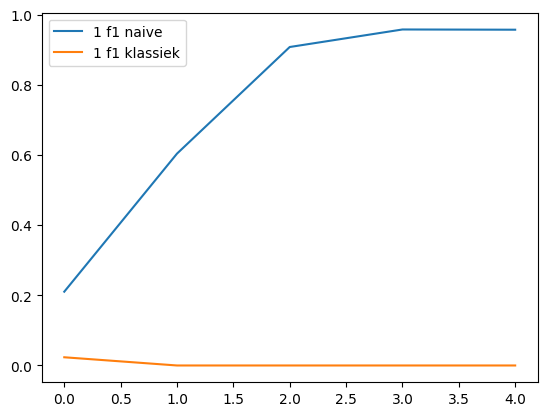

In [15]:
df_f1.plot()

In [16]:
data = get_pd_dataset(name="mnist")
X_train,s_train,X_test,y_test = prepare_and_split_data(data,c=1)

In [17]:
clf = ClassicLogReg(tolerance=1e-3)
clf.fit(X_train, s_train)
y_pred = clf.predict(X_test)
step_result = evaluate_step(y_test, y_pred)
step_result

Converged after 75 iterations


accuracy          0.959866
0 precision       0.966761
1 precision       0.952232
0 recall          0.957283
1 recall          0.962787
0 f1              0.961999
1 f1              0.957480
0 support      1428.000000
1 support      1263.000000
Name: results, dtype: float64

In [20]:
def train_mnist(tolerance):
    digits = np.random.choice(["1_7", "3_5", "3_8", "5_8", "6_9"], replace=False)
    data = get_pd_dataset(name=f"mnist_{digits}")
    seed = np.random.randint(0,10000)
    X_train, s_train, X_test, y_test = prepare_and_split_data(data,random_state=seed,c=1)
    Y_TRAIN = CONFIG.true_train_labels
    clf = ClassicLogReg(tolerance=tolerance)
    clf.fit(X_train, Y_TRAIN)
    y_pred = clf.predict(X_test)
    return y_pred, y_test



In [22]:
tolerance = [1e-5, 1e-4, 1e-3,1e-2,1e-1]
for i in tolerance:
    y_pred, y_test = train_mnist(i)
    # Evaluate the model
    accuracy = f1_score(y_test, y_pred)
    print(f"Run {i}: F1 Score = {accuracy:.4f} \n")


Run 1e-05: F1 Score = 0.0000 

Run 0.0001: F1 Score = 0.0000 

Converged after 75 iterations
Run 0.001: F1 Score = 0.9450 

Converged after 18 iterations
Run 0.01: F1 Score = 0.8937 

Converged after 1 iterations
Run 0.1: F1 Score = 0.8190 

